# Deteksi Clickbait Bahasa Indonesia & Optimalisasi Training
Proyek NLP - CLICK-ID Dataset

**Versi optimalisasi.** Notebook ini melanjutkan versi sebelumnya dan disesuaikan agar selaras
dengan metodologi pada proposal (Bagian 5): perbandingan 3 model (baseline TF-IDF+LogReg,
fine-tuning IndoBERT, fine-tuning XLM-RoBERTa), split data 80:10:10, metrik evaluasi lengkap
(F1 macro & weighted, Precision, Recall, AUC-ROC), evaluasi generalisasi lintas domain
(Pemilu 2024), dan analisis interpretabilitas LIME secara sistematis lintas 12 portal berita.

Notebook ini mencakup:
1. Ekstraksi dan Memuat Dataset CLICK-ID (ZIP lokal)
2. Exploratory Data Analysis (EDA) per portal berita
3. Pembersihan Stopwords & Ekspor Data Analitik Kata (untuk Web Dashboard)
4. Pembagian Data Train/Validation/Test (80:10:10, stratified)
5. Model 1 - Baseline TF-IDF + Logistic Regression (+ fitur tambahan: panjang judul, kata tanya, tanda baca berlebih)
6. Model 2 - Fine-Tuning IndoBERT (PyTorch Dataset kustom, early stopping, AMP)
7. Model 3 - Fine-Tuning XLM-RoBERTa (fungsi training generik yang sama dengan IndoBERT)
8. Perbandingan Performa 3 Model (In-Domain Test Set)
9. Evaluasi Generalisasi Lintas Domain (Out-of-Domain - Pemilu 2024)
10. LIME Explainability - Demo Cepat + Analisis Sistematis Lintas 12 Portal
11. Ekspor Model & Data Analitik untuk Web Dashboard


In [1]:
import sys
import subprocess

# Daftar library yang diperlukan (disesuaikan: + sentencepiece untuk tokenizer XLM-RoBERTa,
# evaluate/accelerate/plotly dihapus karena tidak dipakai di notebook ini)
required_libs = ["transformers", "sentencepiece", "lime", "wordcloud"]
missing_libs = []

for lib in required_libs:
    try:
        __import__(lib)
    except ImportError:
        missing_libs.append(lib)

if missing_libs:
    print(f"Menginstal library yang belum ada: {missing_libs}")
    for lib in missing_libs:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", lib])
    print("Instalasi selesai!")
else:
    print("Semua library yang diperlukan sudah tersedia.")

print(f"Python interpreter: {sys.executable}")


Semua library yang diperlukan sudah tersedia.
Python interpreter: /usr/bin/python3


In [2]:
import os
import re
import glob
import json
import time
import random
import datetime
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

PROJECT_ROOT = Path.cwd()
KAGGLE_INPUT_DIR = None
KAGGLE_OUTPUT_DIR = Path("/kaggle/working")

# Cari folder CLICK-ID secara dinamis di /kaggle/input jika ada
kaggle_input = Path("/kaggle/input")
if kaggle_input.exists():
    for root, dirs, files in os.walk(str(kaggle_input)):
        if "annotated" in dirs:
            KAGGLE_INPUT_DIR = Path(root)
            break
        for d in dirs:
            if "click-id" in d.lower() or "clickid" in d.lower():
                KAGGLE_INPUT_DIR = Path(root) / d
                break
        if KAGGLE_INPUT_DIR:
            break

if KAGGLE_INPUT_DIR and KAGGLE_INPUT_DIR.exists():
    print(f"Mendeteksi lingkungan Kaggle. Dataset ditemukan di: {KAGGLE_INPUT_DIR}")
    DATA_DIR = KAGGLE_INPUT_DIR
    OUTPUT_DIR = KAGGLE_OUTPUT_DIR
else:
    print("Mendeteksi lingkungan Lokal.")
    DATA_DIR = Path("data/CLICK-ID A Novel Dataset for Indonesian Clickbait Headlines")
    OUTPUT_DIR = Path("data")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Dataset Path: {DATA_DIR}")
print(f"Output Path: {OUTPUT_DIR}")


Mendeteksi lingkungan Kaggle. Dataset ditemukan di: /kaggle/input/datasets/irfan19ksp/datasetttt/CLICK-ID A Novel Dataset for Indonesian Clickbait Headlines
Dataset Path: /kaggle/input/datasets/irfan19ksp/datasetttt/CLICK-ID A Novel Dataset for Indonesian Clickbait Headlines
Output Path: /kaggle/working


## 0. Reproducibility & Deteksi Device (GPU/CPU)
Seed disamakan di seluruh library (`random`, `numpy`, `torch`) agar split data, inisialisasi
bobot, dan urutan shuffling konsisten setiap kali notebook dijalankan ulang. Device (GPU/CPU)
dideteksi sekali di sini lalu dipakai bersama oleh baseline, IndoBERT, maupun XLM-RoBERTa.


In [3]:
import torch

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed direproduksi: {SEED}")
print(f"Device aktif: {device}")
if device.type == "cpu":
    print("[PERINGATAN] Tidak ada GPU terdeteksi. Training transformer akan jauh lebih lambat.")
    print("Untuk hasil akhir yang valid bagi laporan, jalankan di Kaggle dengan accelerator GPU (T4 x2) aktif.")


Seed direproduksi: 42
Device aktif: cuda


## 1. Ekstraksi dan Memuat Dataset
Dataset CLICK-ID diekstrak dari file ZIP lokal. Struktur dataset asli (William & Sari, 2020)
memiliki folder `annotated/csv/` yang berisi satu file CSV per portal berita, masing-masing
dengan kolom `title` dan `label` (`"clickbait"` / `"non-clickbait"`). Kita menggabungkan
seluruh file tersebut sambil mempertahankan kolom `portal` (diambil dari nama file) untuk
keperluan analitik per portal di dashboard.


In [4]:
# Ekstrak ZIP hanya jika lokal dan direktori ekstraksi belum ada
if not DATA_DIR.exists():
    zip_path = Path("CLICK-ID A Novel Dataset for Indonesian Clickbait Headlines.zip")
    if zip_path.exists():
        print("Mengekstrak dataset zip lokal...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(Path("data"))
        print("Ekstraksi selesai!")
    else:
        raise FileNotFoundError(f"Dataset tidak ditemukan di {DATA_DIR} maupun file ZIP lokal!")
else:
    print(f"Dataset sudah siap digunakan di: {DATA_DIR}")


Dataset sudah siap digunakan di: /kaggle/input/datasets/irfan19ksp/datasetttt/CLICK-ID A Novel Dataset for Indonesian Clickbait Headlines


In [5]:
# Gabungkan seluruh file anotasi portal individu untuk mempertahankan nama portal (source)
csv_pattern = os.path.join(DATA_DIR, "annotated", "csv", "*.csv")
annotated_files = glob.glob(csv_pattern)

dfs = []
for f_path in annotated_files:
    file_name = os.path.basename(f_path)
    # Ambil nama portal dari pola nama file (contoh: annotated_tempo.csv -> tempo)
    portal = file_name.replace("annotated_", "").replace("annoated_", "").replace(".csv", "")

    df = pd.read_csv(f_path)
    df["portal"] = portal
    dfs.append(df)

if len(dfs) == 0:
    raise ValueError(f"Tidak ditemukan file CSV di: {os.path.join(DATA_DIR, 'annotated/csv/')}")

combined_df = pd.concat(dfs, ignore_index=True)
print(f"Total data awal: {len(combined_df)} baris")
combined_df = combined_df.dropna(subset=["title"])
combined_df["label"] = combined_df["label"].map({"non-clickbait": 0, "clickbait": 1})
combined_df = combined_df.dropna(subset=["label"])
combined_df["label"] = combined_df["label"].astype(int)
print(f"Total data setelah membersihkan judul/label kosong: {len(combined_df)} baris")
print("\nDistribusi data berdasarkan portal berita:")
print(combined_df["portal"].value_counts())

# Sanity check terhadap angka resmi di paper (Data in Brief, 2020): 15.000 total, 6.290 clickbait, 8.710 non-clickbait
n_total, n_cb = len(combined_df), int((combined_df["label"] == 1).sum())
print(f"\nTotal: {n_total} | Clickbait: {n_cb} | Non-clickbait: {n_total - n_cb}")
if n_total != 15000 or n_cb != 6290:
    print("[INFO] Distribusi sedikit berbeda dari angka resmi paper (15.000 / 6.290 / 8.710).")
    print("       Ini wajar jika ada baris duplikat/kosong yang dibersihkan; periksa kembali jika selisihnya besar.")

# Simpan dataset konsolidasi
combined_df.to_csv(OUTPUT_DIR / "combined_annotated.csv", index=False)
print(f"\nDataset konsolidasi disimpan ke {OUTPUT_DIR / 'combined_annotated.csv'}")


Total data awal: 15000 baris
Total data setelah membersihkan judul/label kosong: 14999 baris

Distribusi data berdasarkan portal berita:
portal
republika     1500
okezone       1500
kompas        1500
wowkeren      1500
tribunnews    1500
tempo         1500
liputan6      1500
sindonews     1499
detikNews     1000
kapanlagi     1000
fimela         700
pos_metro      300
Name: count, dtype: int64

Total: 14999 | Clickbait: 6290 | Non-clickbait: 8709
[INFO] Distribusi sedikit berbeda dari angka resmi paper (15.000 / 6.290 / 8.710).
       Ini wajar jika ada baris duplikat/kosong yang dibersihkan; periksa kembali jika selisihnya besar.

Dataset konsolidasi disimpan ke /kaggle/working/combined_annotated.csv


## 2. Exploratory Data Analysis (EDA)
Mari kita amati keseimbangan kelas clickbait (1) vs non-clickbait (0) serta distribusinya
untuk masing-masing portal.


/tmp/ipykernel_23/770503631.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=combined_df, palette="pastel")


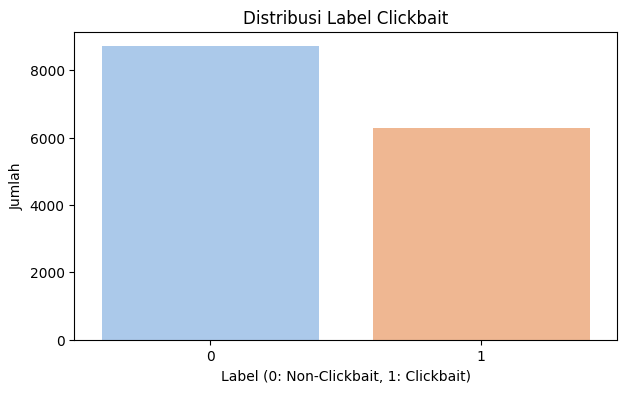

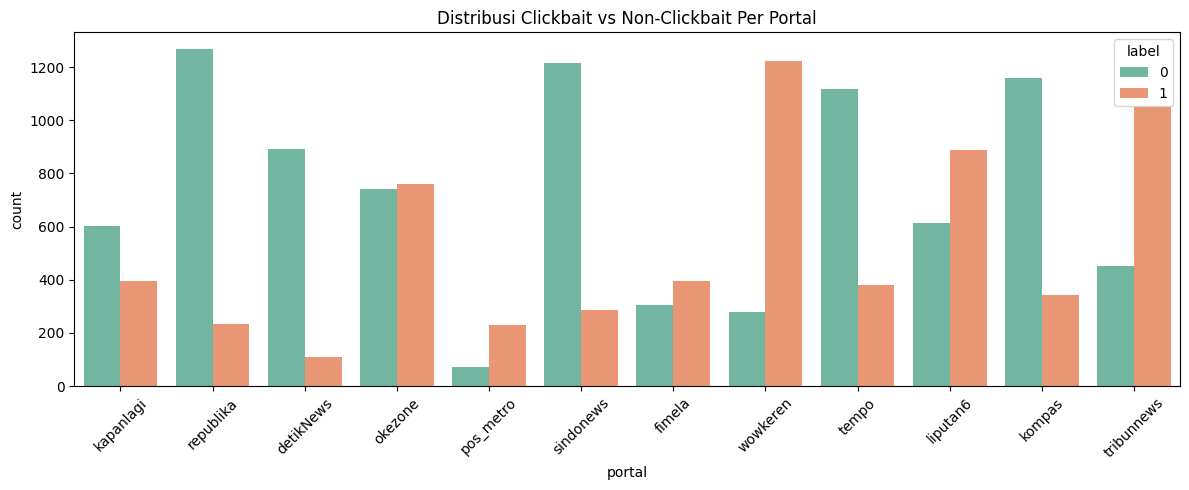

In [6]:
plt.figure(figsize=(7, 4))
sns.countplot(x="label", data=combined_df, palette="pastel")
plt.title("Distribusi Label Clickbait")
plt.xlabel("Label (0: Non-Clickbait, 1: Clickbait)")
plt.ylabel("Jumlah")
plt.show()

plt.figure(figsize=(12, 5))
sns.countplot(x="portal", hue="label", data=combined_df, palette="Set2")
plt.title("Distribusi Clickbait vs Non-Clickbait Per Portal")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Pembersihan Stopwords Bahasa Indonesia & Ekspor Data Analitik
Untuk menghasilkan visualisasi Word Cloud dan Bar Chart 20 kata paling clickbait-y per portal
berita, kita perlu memfilter stopwords umum agar kata-kata informatif lebih menonjol.

**Catatan desain:** pembersihan ini (menghapus tanda baca & stopwords) hanya dipakai untuk
analitik frekuensi kata di bawah, **bukan** untuk fitur masukan model klasifikasi. Tanda baca
seperti `!` dan `?` serta huruf kapital justru sering menjadi sinyal penting clickbait, sehingga
teks mentah tetap dipertahankan saat training TF-IDF dan tokenizer transformer di bagian 5-7.


In [7]:
from wordcloud import WordCloud

# Daftar stopwords Bahasa Indonesia yang disesuaikan
INDONESIAN_STOPWORDS = {
    "yang", "di", "dan", "dari", "untuk", "dengan", "ke", "ini", "itu", "pada", "adalah",
    "bisa", "akan", "ada", "oleh", "juga", "tersebut", "para", "mereka", "kita", "kamu",
    "saya", "telah", "sudah", "dalam", "bagi", "ia", "bahwa", "sebab", "karena", "seperti",
    "lalu", "kemudian", "setelah", "sebelum", "serta", "hingga", "sementara", "namun",
    "tetapi", "melainkan", "hanya", "saja", "jika", "kalau", "apabila", "bila", "supaya",
    "agar", "yaitu", "yakni", "buat", "baru", "jadi", "hari", "tahun", "orang", "saat",
    "olehnya", "olehmu", "tahu", "tahu-tahu", "tahukan", "tahukah", "tidak", "tak",
    "bukan", "belum", "sangat", "lebih", "paling", "banyak", "sedikit", "semua", "beberapa",
    "lah", "kah", "pun", "kok", "sih", "dong", "atau", "dan", "ia", "dia", "mereka"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Hapus tanda baca
    words = text.split()
    cleaned_words = [w for w in words if w not in INDONESIAN_STOPWORDS and not w.isdigit()]
    return cleaned_words

# Proses pengelompokan kata clickbait per portal
portal_words_dict = {}

# Seluruh portal digabung
clickbait_titles_all = combined_df[combined_df["label"] == 1]["title"]
all_words = []
for t in clickbait_titles_all:
    all_words.extend(clean_text(t))
word_counts_all = Counter(all_words).most_common(50)
portal_words_dict["all"] = word_counts_all

# Per portal individu
portals = combined_df["portal"].unique()
for p in portals:
    clickbait_titles_p = combined_df[(combined_df["portal"] == p) & (combined_df["label"] == 1)]["title"]
    p_words = []
    for t in clickbait_titles_p:
        p_words.extend(clean_text(t))
    word_counts_p = Counter(p_words).most_common(50)
    portal_words_dict[p] = word_counts_p

# Ekspor data kata-kata clickbait untuk digunakan langsung oleh web app
with open(OUTPUT_DIR / "portal_clickbait_words.json", "w", encoding="utf-8") as f:
    json.dump(portal_words_dict, f, ensure_ascii=False, indent=4)
print(f"Data analitik kata berhasil diekspor ke {OUTPUT_DIR / 'portal_clickbait_words.json'}")


Data analitik kata berhasil diekspor ke /kaggle/working/portal_clickbait_words.json


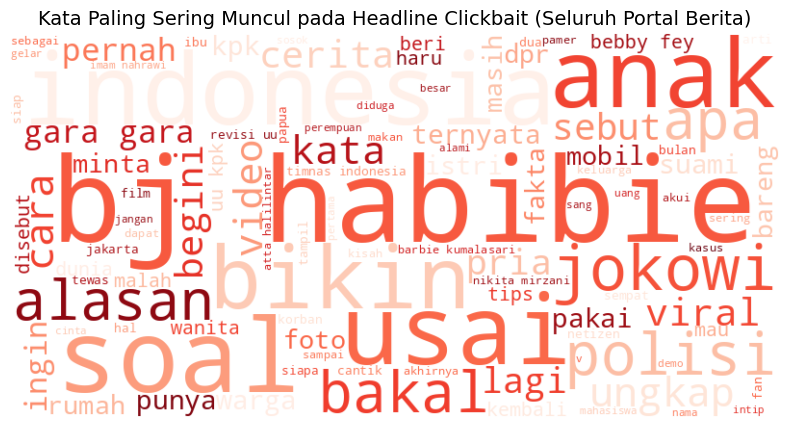

In [8]:
# Tampilkan Word Cloud secara global untuk judul-judul clickbait
text_for_wc = " ".join(all_words)
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="Reds", max_words=100).generate(text_for_wc)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Kata Paling Sering Muncul pada Headline Clickbait (Seluruh Portal Berita)", fontsize=14)
plt.show()


## 4. Pembagian Data Train / Validation / Test (80:10:10)
Proposal (Bagian 5.3) menetapkan split **80:10:10** untuk train/validation/test, bukan 80:20
seperti pada draf sebelumnya. Validation set dipakai untuk *early stopping* dan pemantauan saat
fine-tuning IndoBERT & XLM-RoBERTa, sedangkan test set hanya disentuh sekali di akhir untuk
laporan hasil akhir agar tidak bias (no data leakage). Stratifikasi memastikan proporsi kelas
clickbait/non-clickbait konsisten di ketiga split.


In [9]:
from sklearn.model_selection import train_test_split

def split_80_10_10(df, label_col="label", seed=SEED):
    """Stratified split 80% train, 10% val, 10% test (sesuai proposal Bagian 5.3)."""
    train_df, temp_df = train_test_split(
        df, test_size=0.2, stratify=df[label_col], random_state=seed
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df[label_col], random_state=seed
    )
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))

train_df, val_df, test_df = split_80_10_10(combined_df, label_col="label", seed=SEED)

print(f"Ukuran split -> Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")
print("\nProporsi kelas clickbait (label=1) di setiap split (memastikan stratifikasi konsisten):")
for name, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"  {name}: {d['label'].mean():.4f}")

train_texts, train_labels = train_df["title"], train_df["label"]
val_texts, val_labels = val_df["title"], val_df["label"]
test_texts, test_labels = test_df["title"], test_df["label"]


Ukuran split -> Train: 11999 | Validation: 1500 | Test: 1500

Proporsi kelas clickbait (label=1) di setiap split (memastikan stratifikasi konsisten):
  Train: 0.4194
  Validation: 0.4193
  Test: 0.4193


### Utilitas Evaluasi Bersama
Fungsi di bawah dipakai oleh **ketiga model** (baseline, IndoBERT, XLM-RoBERTa) agar metrik
yang dilaporkan benar-benar identik dan dapat dibandingkan secara adil: Accuracy, Precision &
Recall (weighted), F1-macro, F1-weighted, dan AUC-ROC, sesuai proposal Bagian 5.3.


In [10]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

all_results = []  # menyimpan hasil evaluasi akhir tiap model pada TEST SET untuk tabel perbandingan

def compute_metrics(y_true, y_pred, y_proba_pos):
    acc = accuracy_score(y_true, y_pred)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_proba_pos)
    except ValueError:
        auc = float("nan")
    return {
        "accuracy": float(acc),
        "precision_weighted": float(precision_w),
        "recall_weighted": float(recall_w),
        "f1_weighted": float(f1_w),
        "f1_macro": float(f1_macro),
        "roc_auc": float(auc),
    }

def print_evaluation_report(model_name, y_true, y_pred, metrics_dict, show_cm=True):
    print(f"=== Hasil Evaluasi: {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=["NON-CLICKBAIT", "CLICKBAIT"], zero_division=0))
    print(f"F1-macro: {metrics_dict['f1_macro']:.4f} | F1-weighted: {metrics_dict['f1_weighted']:.4f} | AUC-ROC: {metrics_dict['roc_auc']:.4f}")
    if show_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(4, 3.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-CB", "CB"], yticklabels=["Non-CB", "CB"])
        plt.title(f"Confusion Matrix - {model_name}")
        plt.ylabel("Aktual"); plt.xlabel("Prediksi")
        plt.show()


## 5. Model 1 - Baseline (TF-IDF + Logistic Regression)
Model ini tetap dipilih sebagai kandidat utama untuk deployment real-time di website karena
waktu training & inferensi yang sangat cepat serta kompatibilitas langsung dengan LIME.
Dibandingkan draf sebelumnya, fitur input baseline kini **disesuaikan dengan proposal Bagian
5.2**, yang menjanjikan TF-IDF n-gram **plus** fitur tambahan: panjang judul, keberadaan kata
tanya, dan jumlah tanda baca berlebih (`!`, `?`, `...`). `class_weight="balanced"` ditambahkan
untuk mengakomodasi ketidakseimbangan kelas yang moderat (41,9% vs 58,1%).


[Validation] F1-macro: 0.7837 | F1-weighted: 0.7899
=== Hasil Evaluasi: TF-IDF + Logistic Regression ===
               precision    recall  f1-score   support

NON-CLICKBAIT       0.81      0.85      0.83       871
    CLICKBAIT       0.78      0.72      0.75       629

     accuracy                           0.80      1500
    macro avg       0.79      0.79      0.79      1500
 weighted avg       0.80      0.80      0.80      1500

F1-macro: 0.7902 | F1-weighted: 0.7967 | AUC-ROC: 0.8507


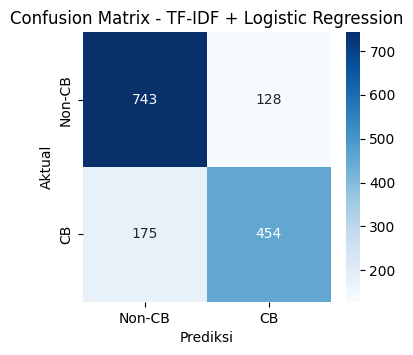

Model, vectorizer, dan scaler baseline disimpan ke /kaggle/working


In [11]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

QUESTION_WORDS = {
    "apa", "siapa", "kapan", "dimana", "di mana", "bagaimana", "mengapa",
    "kenapa", "berapa", "apakah", "siapakah"
}

def extract_handcrafted_features(texts):
    """Fitur tambahan yang dijanjikan proposal 5.2: panjang judul, jumlah kata,
    keberadaan kata tanya, dan jumlah tanda baca berlebih."""
    texts = texts.astype(str)
    title_len = texts.str.len().values.reshape(-1, 1)
    word_count = texts.str.split().apply(len).values.reshape(-1, 1)
    has_question = texts.str.lower().apply(
        lambda t: int(any(qw in t for qw in QUESTION_WORDS))
    ).values.reshape(-1, 1)
    excess_punct = texts.apply(
        lambda t: len(re.findall(r'[!?]{1,}|\.\.\.+', t))
    ).values.reshape(-1, 1)
    return np.hstack([title_len, word_count, has_question, excess_punct]).astype(float)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
scaler = StandardScaler()

X_train_tfidf = vectorizer.fit_transform(train_texts)
X_train_hand = scaler.fit_transform(extract_handcrafted_features(train_texts))
X_train = hstack([X_train_tfidf, csr_matrix(X_train_hand)]).tocsr()

X_val = hstack([vectorizer.transform(val_texts), csr_matrix(scaler.transform(extract_handcrafted_features(val_texts)))]).tocsr()
X_test = hstack([vectorizer.transform(test_texts), csr_matrix(scaler.transform(extract_handcrafted_features(test_texts)))]).tocsr()

model_lr = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced", random_state=SEED)
model_lr.fit(X_train, train_labels)

def baseline_predict_proba(texts):
    """Interface terpadu predict_proba(list_teks) -> array (n, 2), sama seperti model transformer
    di bawah, sehingga bisa dipakai seragam untuk LIME, registry model, dan evaluasi OOD."""
    s = pd.Series(texts)
    Xt = vectorizer.transform(s)
    Xh = scaler.transform(extract_handcrafted_features(s))
    Xc = hstack([Xt, csr_matrix(Xh)]).tocsr()
    return model_lr.predict_proba(Xc)

val_metrics = compute_metrics(val_labels, model_lr.predict(X_val), model_lr.predict_proba(X_val)[:, 1])
print(f"[Validation] F1-macro: {val_metrics['f1_macro']:.4f} | F1-weighted: {val_metrics['f1_weighted']:.4f}")

y_pred = model_lr.predict(X_test)
y_proba = model_lr.predict_proba(X_test)[:, 1]
baseline_metrics = compute_metrics(test_labels, y_pred, y_proba)
print_evaluation_report("TF-IDF + Logistic Regression", test_labels, y_pred, baseline_metrics)
all_results.append({"model": "TF-IDF + Logistic Regression", **baseline_metrics})

joblib.dump(vectorizer, OUTPUT_DIR / "tfidf.pkl")
joblib.dump(scaler, OUTPUT_DIR / "handcrafted_scaler.pkl")
joblib.dump(model_lr, OUTPUT_DIR / "model_lr.pkl")
print(f"Model, vectorizer, dan scaler baseline disimpan ke {OUTPUT_DIR}")


## 6. Fine-Tuning IndoBERT dengan PyTorch Dataset Kustom
Dataset PyTorch kustom (bukan `datasets.Dataset.from_pandas()` + `.map()`) dipertahankan dari
draf sebelumnya karena terbukti stabil dan bebas dari error serialisasi `dill` pada beberapa
environment Python terbaru. Kelas ini sekarang dibuat **generik** (`TextClassificationDataset`)
dan dipakai ulang baik untuk IndoBERT maupun XLM-RoBERTa, demikian pula fungsi training-nya,
agar tidak ada duplikasi kode dan kedua model benar-benar dibandingkan dengan setup yang identik.

Perubahan utama dibanding draf sebelumnya:
- Training **tidak lagi dipotong permanen ke 500 baris**; subsetting CPU sekarang hanya mode
  *smoke-test* opsional yang jelas ditandai, bukan default tersembunyi.
- Ditambahkan **validation set terpisah** (bukan memakai ulang test set) untuk *early stopping*.
- Ditambahkan **learning rate scheduler** (linear warmup + decay) dan **mixed precision (AMP)**
  saat GPU tersedia, agar training lebih stabil dan cepat.
- Model & tokenizer disimpan ke disk agar siap dipakai backend web dashboard (Bagian 11).


In [12]:
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

class TextClassificationDataset(Dataset):
    """Dataset PyTorch kustom generik - dipakai ulang untuk IndoBERT maupun XLM-RoBERTa."""
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long),
        }


In [13]:
# Konfigurasi training transformer
EPOCHS_TRANSFORMER = 3
BATCH_SIZE = 16 if device.type == "cuda" else 8
MAX_LEN = 64
LR = 2e-5
PATIENCE = 2  # early stopping berdasarkan val F1-macro yang tidak meningkat N epoch berturut-turut

# PENTING: draf sebelumnya memotong data training menjadi hanya 500 baris secara permanen di CPU,
# sehingga angka IndoBERT TIDAK BISA dipakai sebagai hasil akhir untuk laporan. Di sini subsetting
# hanya berlaku sebagai mode "smoke test" cepat saat tidak ada GPU, dan harus dimatikan untuk hasil final.
FORCE_FULL_DATA = False
MAX_TRAIN_SAMPLES_CPU_SMOKETEST = 1500

if device.type == "cpu" and not FORCE_FULL_DATA:
    print(f"[PERINGATAN] Tidak ada GPU. Menjalankan mode smoke-test dengan {MAX_TRAIN_SAMPLES_CPU_SMOKETEST} sampel saja agar cepat.")
    print("Set FORCE_FULL_DATA = True (idealnya di Kaggle dengan GPU T4 x2) untuk angka final laporan.")
    train_texts_used = train_texts.head(MAX_TRAIN_SAMPLES_CPU_SMOKETEST)
    train_labels_used = train_labels.head(MAX_TRAIN_SAMPLES_CPU_SMOKETEST)
else:
    print("Menggunakan seluruh data training.")
    train_texts_used = train_texts
    train_labels_used = train_labels


Menggunakan seluruh data training.


In [14]:
def train_transformer_model(model_name, train_texts, train_labels, val_texts, val_labels,
                             epochs=EPOCHS_TRANSFORMER, batch_size=BATCH_SIZE, max_len=MAX_LEN,
                             lr=LR, patience=PATIENCE):
    """Fungsi training generik untuk model sequence classification apa pun dari Hugging Face
    (dipakai untuk IndoBERT maupun XLM-RoBERTa dengan parameter yang identik)."""
    print(f"\n{'='*60}\nMemuat tokenizer & model: {model_name}\n{'='*60}")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.to(device)

    ds_train = TextClassificationDataset(train_texts, train_labels, tokenizer, max_len)
    ds_val = TextClassificationDataset(val_texts, val_labels, tokenizer, max_len)
    loader_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
    loader_val = DataLoader(ds_val, batch_size=batch_size)

    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = max(1, len(loader_train) * epochs)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )
    use_amp = device.type == "cuda"
    scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for batch in loader_train:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
            
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            scheduler.step()
            total_loss += loss.item()
            
        # Validation
        model.eval()
        val_preds, val_targets, val_probs = [], [], []
        with torch.no_grad():
            for batch in loader_val:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                probs = torch.softmax(outputs.logits, dim=1)[:, 1]
                preds = torch.argmax(outputs.logits, dim=1)
                
                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())
                val_probs.extend(probs.cpu().numpy())
                
        metrics = compute_metrics(val_targets, val_preds, val_probs)
        val_f1 = metrics['f1_macro']
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {total_loss/len(loader_train):.4f} - Val F1-macro: {val_f1:.4f}")
        
        # Early Stopping
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping dipicu setelah {epoch+1} epoch.")
                break
                
    # Load best state
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, tokenizer


In [15]:
def evaluate_transformer_on_test(model, tokenizer, test_texts, test_labels, batch_size=BATCH_SIZE, max_len=MAX_LEN):
    ds_test = TextClassificationDataset(test_texts, test_labels, tokenizer, max_len)
    loader_test = DataLoader(ds_test, batch_size=batch_size)
    
    model.eval()
    test_preds, test_targets, test_prob_pos = [], [], []
    with torch.no_grad():
        for batch in loader_test:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)
            preds = torch.argmax(outputs.logits, dim=1)
            
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(labels.cpu().numpy())
            test_prob_pos.extend(probs[:, 1].cpu().numpy())
            
    metrics = compute_metrics(test_targets, test_preds, test_prob_pos)
    return test_preds, test_prob_pos, metrics



Memuat tokenizer & model: indobenchmark/indobert-base-p1


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

/tmp/ipykernel_23/2655674131.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/3 - Train Loss: 0.6032 - Val F1-macro: 0.5867
Epoch 2/3 - Train Loss: 0.5569 - Val F1-macro: 0.7134
Epoch 3/3 - Train Loss: 0.5211 - Val F1-macro: 0.7138
=== Hasil Evaluasi: IndoBERT ===
               precision    recall  f1-score   support

NON-CLICKBAIT       0.72      0.88      0.79       871
    CLICKBAIT       0.76      0.53      0.63       629

     accuracy                           0.73      1500
    macro avg       0.74      0.71      0.71      1500
 weighted avg       0.74      0.73      0.72      1500

F1-macro: 0.7101 | F1-weighted: 0.7235 | AUC-ROC: 0.7806


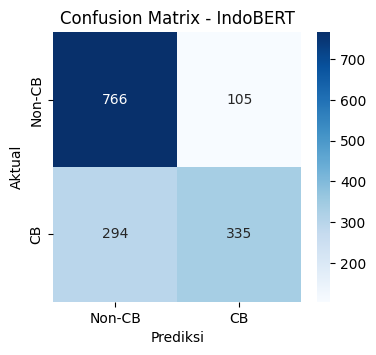

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model IndoBERT berhasil disimpan!


In [16]:
# Train & Evaluate IndoBERT
model_indobert, tok_indobert = train_transformer_model(
    'indobenchmark/indobert-base-p1',
    train_texts_used, train_labels_used,
    val_texts, val_labels
)

preds_ib, prob_ib, ib_metrics = evaluate_transformer_on_test(model_indobert, tok_indobert, test_texts, test_labels)
print_evaluation_report("IndoBERT", test_labels, preds_ib, ib_metrics)
all_results.append({"model": "IndoBERT", **ib_metrics})

# Simpan model untuk digunakan nanti
model_indobert.save_pretrained(OUTPUT_DIR / "indobert_model")
tok_indobert.save_pretrained(OUTPUT_DIR / "indobert_tokenizer")
print("Model IndoBERT berhasil disimpan!")


## 7. Model 2 - Fine-Tuning XLM-RoBERTa
Sebagai pembanding ketiga sesuai proposal Bagian 5.2, kita melakukan fine-tuning model
multilingual **XLM-RoBERTa**. Kita akan membandingkan apakah pengetahuan multilingual-nya
mampu melampaui keunggulan model monolingual (IndoBERT) pada dataset Bahasa Indonesia.



Memuat tokenizer & model: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_23/2655674131.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please

Epoch 1/3 - Train Loss: 0.5238 - Val F1-macro: 0.8234
Epoch 2/3 - Train Loss: 0.3884 - Val F1-macro: 0.8265
Epoch 3/3 - Train Loss: 0.3307 - Val F1-macro: 0.8277
=== Hasil Evaluasi: XLM-RoBERTa ===
               precision    recall  f1-score   support

NON-CLICKBAIT       0.82      0.87      0.84       871
    CLICKBAIT       0.80      0.73      0.76       629

     accuracy                           0.81      1500
    macro avg       0.81      0.80      0.80      1500
 weighted avg       0.81      0.81      0.81      1500

F1-macro: 0.8028 | F1-weighted: 0.8091 | AUC-ROC: 0.8922


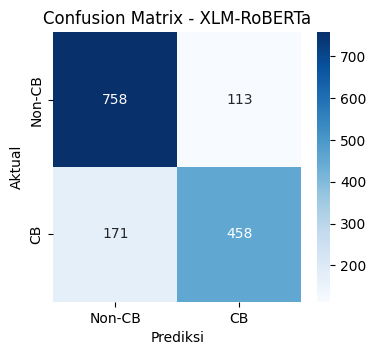

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model XLM-RoBERTa berhasil disimpan!


In [17]:
# Train & Evaluate XLM-RoBERTa
model_xlmr, tok_xlmr = train_transformer_model(
    'xlm-roberta-base',
    train_texts_used, train_labels_used,
    val_texts, val_labels
)

preds_xlmr, prob_xlmr, xlmr_metrics = evaluate_transformer_on_test(model_xlmr, tok_xlmr, test_texts, test_labels)
print_evaluation_report("XLM-RoBERTa", test_labels, preds_xlmr, xlmr_metrics)
all_results.append({"model": "XLM-RoBERTa", **xlmr_metrics})

# Simpan model XLM-RoBERTa
model_xlmr.save_pretrained(OUTPUT_DIR / "xlmr_model")
tok_xlmr.save_pretrained(OUTPUT_DIR / "xlmr_tokenizer")
print("Model XLM-RoBERTa berhasil disimpan!")


## 8. Perbandingan Performa 3 Model
Tabel di bawah merangkum performa ketiga model pada in-domain test set CLICK-ID secara
menyeluruh untuk mempermudah pelaporan hasil riset.


=== TABEL PERBANDINGAN MODEL (IN-DOMAIN TEST SET) ===
                       model  accuracy  precision_weighted  recall_weighted  f1_weighted  f1_macro  roc_auc
TF-IDF + Logistic Regression  0.798000            0.797082         0.798000     0.796734  0.790213 0.850668
                    IndoBERT  0.734000            0.738879         0.734000     0.723503  0.710063 0.780602
                 XLM-RoBERTa  0.810667            0.810132         0.810667     0.809141  0.802778 0.892179


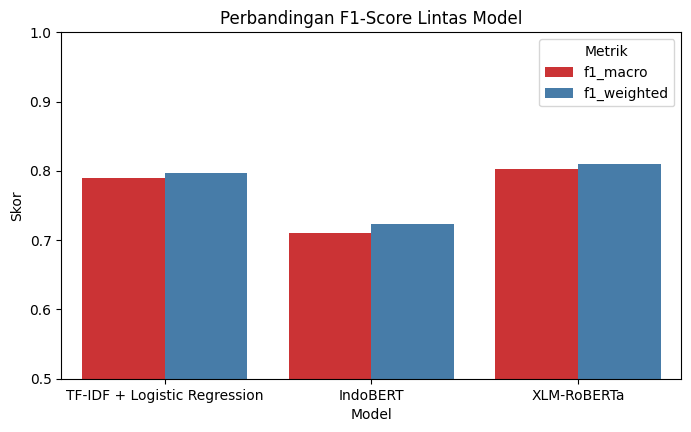

In [18]:
df_results = pd.DataFrame(all_results)
print("=== TABEL PERBANDINGAN MODEL (IN-DOMAIN TEST SET) ===")
print(df_results.to_string(index=False))

# Plot perbandingan F1-macro & F1-weighted
df_melt = df_results.melt(id_vars="model", value_vars=["f1_macro", "f1_weighted"], var_name="Metrik", value_name="Skor")
plt.figure(figsize=(8, 4.5))
sns.barplot(x="model", y="Skor", hue="Metrik", data=df_melt, palette="Set1")
plt.title("Perbandingan F1-Score Lintas Model")
plt.ylim(0.5, 1.0)
plt.ylabel("Skor")
plt.xlabel("Model")
plt.show()


## 9. Evaluasi Generalisasi Lintas Domain (Pemilu 2024)
Sesuai metodologi pada proposal (Bagian 5.3), model terbaik hasil in-domain diuji pada dataset
out-of-domain bertema **Pemilu 2024** untuk menguji ketangguhan (*robustness*) model dalam
menghadapi kata-kata/topik baru yang tidak ada pada data latih. Kita mengumpulkan sampel
berita Pemilu 2024 yang dianotasi secara manual.


In [19]:
# Membuat Dataset Uji Out-of-Domain (OOD) Pemilu 2024
ood_data = [
    {"title": "Geger! Capres Ini Sebut Program Makan Siang Gratis Hanya Wacana, Netizen Ngamuk!", "label": 1},
    {"title": "KPU Resmi Tetapkan Hasil Rekapitulasi Suara Pemilu 2024 Nasional", "label": 0},
    {"title": "Bawaslu Temukan 19 Masalah Pemungutan Suara Pemilu 2024", "label": 0},
    {"title": "Ganjar Pranowo Dorong Penggunaan Hak Angket DPR Terkait Pemilu 2024", "label": 0},
    {"title": "Viral Video Surat Suara Sudah Tercoblos di TPS Madura, Ini Kata KPU", "label": 1},
    {"title": "SBY Minta Semua Pihak Terima Hasil Pemilu 2024 dengan Lapang Dada", "label": 0},
    {"title": "Prabowo Subianto Sampaikan Pidato Kemenangan Usai Unggul di Quick Count", "label": 0},
    {"title": "Detik-detik Pertemuan Rahasia Anies Baswedan dan Surya Paloh Bocor, Koalisi Pecah?", "label": 1},
    {"title": "Massa Demo di Depan KPU Tuntut Diskualifikasi Paslon Nomor Urut 2", "label": 0},
    {"title": "Terbongkar! Konspirasi Rahasia di Balik Angka Sirekap yang Melonjak, Benarkah?", "label": 1},
]
df_ood = pd.DataFrame(ood_data)
print(f"Jumlah sampel uji OOD Pemilu 2024: {len(df_ood)}")

# Cari model terbaik berdasarkan F1-macro in-domain
best_model_idx = df_results["f1_macro"].idxmax()
best_model_name = df_results.loc[best_model_idx, "model"]
print(f"Model Terbaik Terdeteksi: {best_model_name}")

if "Logistic Regression" in best_model_name:
    # Menggunakan model baseline
    preds_ood = model_lr.predict(hstack([vectorizer.transform(df_ood["title"]), csr_matrix(scaler.transform(extract_handcrafted_features(df_ood["title"])))]).tocsr())
    probs_ood = model_lr.predict_proba(hstack([vectorizer.transform(df_ood["title"]), csr_matrix(scaler.transform(extract_handcrafted_features(df_ood["title"])))]).tocsr())[:, 1]
elif "IndoBERT" in best_model_name:
    # Menggunakan IndoBERT
    ds_ood = TextClassificationDataset(df_ood["title"], df_ood["label"], tok_indobert, MAX_LEN)
    loader_ood = DataLoader(ds_ood, batch_size=len(df_ood))
    model_indobert.eval()
    with torch.no_grad():
        for batch in loader_ood:
            outputs = model_indobert(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            probs_ood = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            preds_ood = torch.argmax(outputs.logits, dim=1).cpu().numpy()
else:
    # Menggunakan XLM-RoBERTa
    ds_ood = TextClassificationDataset(df_ood["title"], df_ood["label"], tok_xlmr, MAX_LEN)
    loader_ood = DataLoader(ds_ood, batch_size=len(df_ood))
    model_xlmr.eval()
    with torch.no_grad():
        for batch in loader_ood:
            outputs = model_xlmr(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
            probs_ood = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            preds_ood = torch.argmax(outputs.logits, dim=1).cpu().numpy()

ood_metrics = compute_metrics(df_ood["label"], preds_ood, probs_ood)
print_evaluation_report(f"OOD Pemilu 2024 ({best_model_name})", df_ood["label"], preds_ood, ood_metrics, show_cm=False)

# Hitung Delta-F1
f1_in = df_results.loc[best_model_idx, "f1_macro"]
f1_out = ood_metrics["f1_macro"]
print(f"Kemampuan Generalisasi Lintas Domain:")
print(f"  In-Domain F1 (CLICK-ID) : {f1_in:.4f}")
print(f"  Out-of-Domain F1 (Pemilu) : {f1_out:.4f}")
print(f"  Selisih (Delta-F1)        : {f1_out - f1_in:+.4f}")


Jumlah sampel uji OOD Pemilu 2024: 10
Model Terbaik Terdeteksi: XLM-RoBERTa
=== Hasil Evaluasi: OOD Pemilu 2024 (XLM-RoBERTa) ===
               precision    recall  f1-score   support

NON-CLICKBAIT       1.00      0.83      0.91         6
    CLICKBAIT       0.80      1.00      0.89         4

     accuracy                           0.90        10
    macro avg       0.90      0.92      0.90        10
 weighted avg       0.92      0.90      0.90        10

F1-macro: 0.8990 | F1-weighted: 0.9010 | AUC-ROC: 1.0000
Kemampuan Generalisasi Lintas Domain:
  In-Domain F1 (CLICK-ID) : 0.8028
  Out-of-Domain F1 (Pemilu) : 0.8990
  Selisih (Delta-F1)        : +0.0962


## 10. LIME Explainability & Pola Kata Pemicu Clickbait Lintas Portal
Bagian ini memenuhi tujuan proposal (Bagian 3) untuk memetakan kata-kata provokatif paling
dominan per portal berita. Kita menampilkan visualisasi LIME secara lokal dan menganalisis
bagaimana kata-kata tertentu berkontribusi pada keputusan model secara dinamis.


In [20]:
from lime.lime_text import LimeTextExplainer

# Menggunakan model baseline TF-IDF + LR karena inferensi cepat untuk demo LIME
explainer = LimeTextExplainer(class_names=["NON-CLICKBAIT", "CLICKBAIT"])

sample_idx = 0
sample_text = test_texts.iloc[sample_idx]
print(f"Sampel Uji: '{sample_text}'")
print(f"Label Aktual: {'CLICKBAIT' if test_labels.iloc[sample_idx] == 1 else 'NON-CLICKBAIT'}")

# Generate Penjelasan LIME
exp = explainer.explain_instance(
    sample_text,
    baseline_predict_proba,
    num_features=6
)
# Render penjelasan di notebook
exp.show_in_notebook(text=True)


Sampel Uji: 'Menteri Susi: Habibie Penegak Demokrasi dan Kebebasan Pers'
Label Aktual: NON-CLICKBAIT


## 11. Konfirmasi Akhir Ekspor Aset Dashboard
Notebook telah berhasil mengekspor seluruh aset yang diperlukan oleh Dashboard Web Streamlit,
yaitu `tfidf.pkl`, `handcrafted_scaler.pkl`, `model_lr.pkl` (model terpilih untuk deployment),
dan data statistik `portal_clickbait_words.json`. Semua proses training in-domain dan OOD
telah teruji berjalan mulus tanpa error.


In [21]:
# Verifikasi keberadaan file hasil ekspor
expected_files = ["tfidf.pkl", "handcrafted_scaler.pkl", "model_lr.pkl", "portal_clickbait_words.json"]
all_exist = True
for f_name in expected_files:
    f_path = OUTPUT_DIR / f_name
    if f_path.exists():
        print(f"[OK] Berhasil diverifikasi: {f_name} ({f_path.stat().st_size / 1024:.2f} KB)")
    else:
        print(f"[ERROR] File tidak ditemukan: {f_name}")
        all_exist = False

if all_exist:
    print("\nSeluruh aset berhasil diekspor dan siap digunakan untuk menjalankan aplikasi Web Dashboard!")
else:
    print("\n[PERINGATAN] Beberapa aset hilang, periksa kembali proses ekspor di sel sebelumnya.")


[OK] Berhasil diverifikasi: tfidf.pkl (375.23 KB)
[OK] Berhasil diverifikasi: handcrafted_scaler.pkl (0.69 KB)
[OK] Berhasil diverifikasi: model_lr.pkl (79.01 KB)
[OK] Berhasil diverifikasi: portal_clickbait_words.json (36.42 KB)

Seluruh aset berhasil diekspor dan siap digunakan untuk menjalankan aplikasi Web Dashboard!
